In [2]:
import pandas as pd
import glob
import numpy as np
import json
import matplotlib.pyplot as plt

In [3]:
files = np.array(glob.glob("dump_*_recov.json"))
recov = np.array([float(f.split('_')[1]) for f in files])
args = np.argsort(recov)
files = files[args]

In [4]:
data = []
for fi in files:
    with open(fi) as f:
        js = json.load(f)

    d = {
        key: js[key] 
        for key in [
            'SEC', 
            'LCOW', 
            'WaterTAP LCOW', 
            'Recovery', 
            'Fixed OM Cost', 
            'Variable OM Cost',
            'Permeate Flow',
            'Annualized Cost'
        ]
    }

    data.append(d)

df_lsrro = pd.DataFrame(data)
df_lsrro = df_lsrro.set_index('Recovery')
df_lsrro

,SEC,LCOW,WaterTAP LCOW,Fixed OM Cost,Variable OM Cost,Permeate Flow,Annualized Cost
Recovery,,,,,,,
0.20,19.155976,6.808468,6.298307,1485.746976,298.349395,0.003054,0.656179
0.30,16.604565,5.334900,4.467245,1485.774764,298.354953,0.004581,0.771242
0.40,16.575300,4.982133,3.638965,1485.822409,298.364482,0.006108,0.960325
0.45,17.706272,5.237361,3.442723,1485.867750,298.373550,0.006872,1.135711
0.50,21.163754,6.240422,3.464418,1485.961252,298.392250,0.007635,1.503581


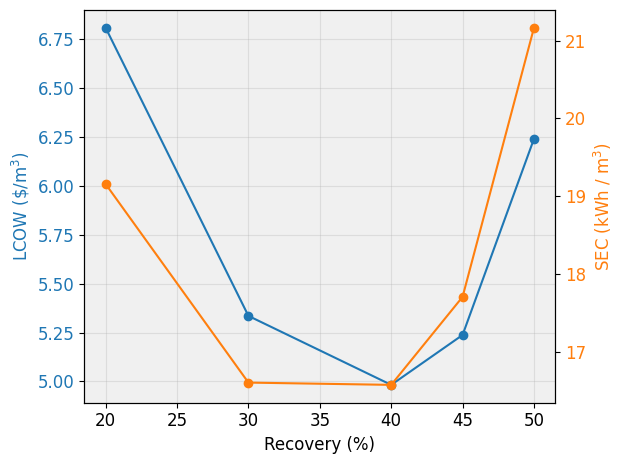

In [5]:
plt.rcParams.update({'font.size': 12})

fig, ax1 = plt.subplots()
lcow_label = 'LCOW (\$/m$^3$)'
sec_label = 'SEC (kWh / m$^3$)'
color = 'tab:blue'
ax1.plot(df_lsrro.index*100, df_lsrro['LCOW'], '-o', color=color)
ax1.set_xlabel('Recovery (%)')
ax1.set_ylabel('LCOW (\$/m$^3$)', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, axis='y', alpha=0.3)
ax1.grid(True, axis='x', alpha=0.3)
ax1.set_facecolor('#f0f0f0')

color = 'tab:orange'
ax2 = ax1.twinx()
ax2.plot(df_lsrro.index*100, df_lsrro['SEC'], '-o', color=color)
ax2.set_ylabel(sec_label, color=color)
ax2.tick_params(axis='y', labelcolor=color)
plt.tight_layout()
plt.savefig('../lcow_sec_lsrro.png', dpi = 400)

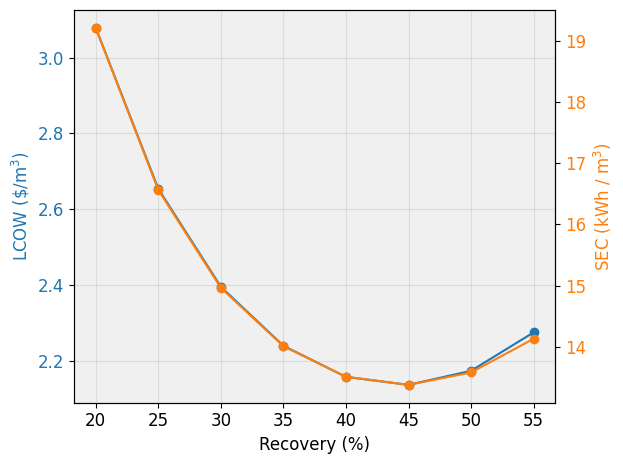

In [9]:
with open('../Train0/results_fixed_recovery.json', 'r') as f:
    data = json.load(f)
df_ro = pd.DataFrame.from_dict(data, orient='index')
df_ro.index = df_ro.index.astype(float).round(2)
df_ro.index.name = 'Recovery'

fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.plot(df_ro['Recovery']*100, df_ro['LCOW'], '-o', color=color)
ax1.set_xlabel('Recovery (%)')
ax1.set_ylabel('LCOW (\$/m$^3$)', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, axis='y', alpha=0.3)
ax1.grid(True, axis='x', alpha=0.3)
ax1.set_facecolor('#f0f0f0')


color = 'tab:orange'
ax2 = ax1.twinx()
ax2.plot(df_ro['Recovery']*100, df_ro['SEC'], '-o', color=color)
ax2.set_ylabel(sec_label, color=color)
ax2.tick_params(axis='y', labelcolor=color)
plt.tight_layout()
plt.savefig('../lcow_sec_ro.png', dpi = 400)

In [ ]:
fig, ax1, ax2 = plt.subplots()

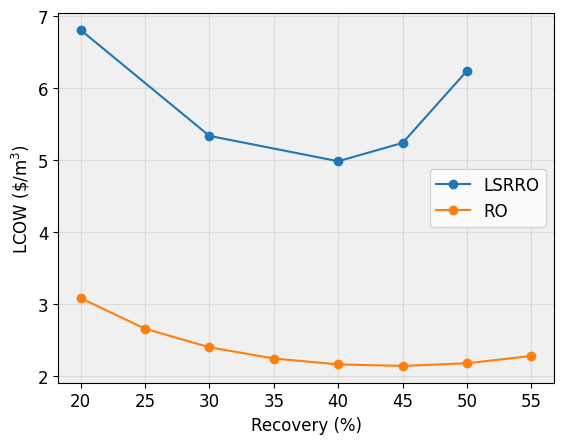

In [16]:
plt.plot(df_lsrro.index*100, df_lsrro['LCOW'], '-o', label='LSRRO')
plt.plot(df_ro['Recovery']*100, df_ro['LCOW'], '-o', label='RO')
plt.xlabel('Recovery (%)')
plt.ylabel(lcow_label)
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().set_facecolor('#f0f0f0')
plt.savefig('../lcow_lsrro_ro.png', dpi = 400)

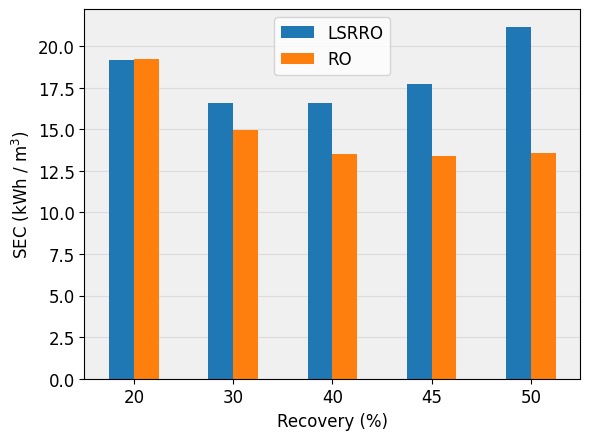

In [21]:
# Get indices present in both dataframes
common_indices = sorted(list(set(df_ro.index) & set(df_lsrro.index)))

# Create plot
pd.DataFrame({
    'LSRRO': df_lsrro.loc[common_indices]['SEC'],
    'RO': df_ro.loc[common_indices]['SEC']
}).plot.bar()

plt.xticks(range(len(common_indices)), [f'{x*100:.0f}' for x in common_indices], rotation=0)
plt.ylabel(sec_label)
plt.grid(True, axis='y', alpha=0.3, zorder=0)
plt.gca().set_facecolor('#f0f0f0')
ax = plt.gca()
plt.xlabel('Recovery (%)')
ax.set_axisbelow(True)
plt.savefig('../sec_lsrro_ro.png', dpi = 400)


In [204]:
df_ro

,SEC,LCOW,Watertap LCOW,Permeate Flow,Brine Flow,Pump Pressure,Membrane Area,Recovery,Variable OM Cost,Fixed OM Cost
Recovery,,,,,,,,,,
0.20,19.206869,3.078916,2.746840,0.003163,0.012673,1.116448e+07,977.919084,0.20,298.335417,1485.677085
0.25,16.560161,2.653645,2.281098,0.003954,0.011888,1.202464e+07,1047.930619,0.25,298.336304,1485.681518
0.30,14.964020,2.394737,1.982387,0.004745,0.011104,1.303024e+07,1113.546209,0.30,298.337315,1485.686576
0.35,14.012301,2.238865,1.782209,0.005536,0.010321,1.422572e+07,1186.336153,0.35,298.338510,1485.692549
0.40,13.514490,2.156768,1.647194,0.006327,0.009539,1.567002e+07,1282.917057,0.40,298.339966,1485.699831
0.45,13.381748,2.135655,1.559993,0.007118,0.008758,1.744407e+07,1429.881377,0.45,298.341799,1485.708993
0.50,13.583797,2.172869,1.511809,0.007909,0.007978,1.966199e+07,1672.805918,0.50,298.344180,1485.720900
0.55,14.133828,2.274211,1.499317,0.008700,0.007200,2.248931e+07,2092.251596,0.55,298.347384,1485.736918
